# Phase 1 - Ingest and audit PAMAP2

## Problem statement
Build a clean, auditable ingestion workflow for PAMAP2 that maps raw `.dat` files to explicit schema columns, audits data quality, and produces a 1-second interim telemetry table for downstream modeling.

## Contract for this notebook
- Regression target for later phases: heart rate at `t + 30 seconds`
- Classification target for later phases: current activity label at `t`
- Uncertainty method for later phases: split conformal on top of final regression model
- Split rule for later phases: subject-held-out

## Scope in this notebook
- Ingest Protocol files as primary source
- Keep Optional files documented separately (not merged into primary audit metrics)
- Audit rows, labels, and missingness by subject
- Build and save `data/interim/pamap2_per_second.parquet`

## Out of scope in this notebook
- Feature engineering beyond compact interim telemetry columns
- Model training
- Hyperparameter tuning
- Any cloud or deployment work

In [1]:
# Import standard libraries for file paths and tabular analysis.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make DataFrame output easier to inspect in notebook cells.
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# Define all project paths used in Phase 1 ingest and audit.
PROJECT_ROOT = Path("..").resolve()
RAW_ROOT = PROJECT_ROOT / "data" / "raw" / "pamap2+physical+activity+monitoring"
RAW_DATASET_ROOT = RAW_ROOT / "PAMAP2_Dataset"
PROTOCOL_DIR = RAW_DATASET_ROOT / "Protocol"
OPTIONAL_DIR = RAW_DATASET_ROOT / "Optional"
METADATA_DIR = RAW_ROOT / "metadata"
INTERIM_PATH = PROJECT_ROOT / "data" / "interim" / "pamap2_per_second.parquet"
ARTIFACT_METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
ARTIFACT_FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"

# Ensure output folders exist before writing files later in the notebook.
ARTIFACT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_PATH.parent.mkdir(parents=True, exist_ok=True)

# Load the schema and activity-label metadata created during Phase 1 setup.
schema_df = pd.read_csv(METADATA_DIR / "schema_columns.csv")
activity_labels_df = pd.read_csv(METADATA_DIR / "activity_labels.csv")

# Normalize activity metadata types so joins/maps are stable and explicit.
activity_labels_df["activity_id"] = pd.to_numeric(activity_labels_df["activity_id"], errors="raise").astype("int64")
activity_labels_df["activity_label"] = activity_labels_df["activity_label"].astype(str)
activity_map = dict(zip(activity_labels_df["activity_id"].tolist(), activity_labels_df["activity_label"].tolist()))

# Keep only columns needed for the MVP ingest/audit pass.
required_columns = [
    "timestamp_s",
    "activity_id",
    "heart_rate_bpm",
    "hand_acc_16g_x",
    "hand_acc_16g_y",
    "hand_acc_16g_z",
    "hand_gyro_x",
    "hand_gyro_y",
    "hand_gyro_z",
    "chest_acc_16g_x",
    "chest_acc_16g_y",
    "chest_acc_16g_z",
    "chest_gyro_x",
    "chest_gyro_y",
    "chest_gyro_z",
    "ankle_acc_16g_x",
    "ankle_acc_16g_y",
    "ankle_acc_16g_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
]

# Convert metadata into a raw-column-index map (0-based) for fast reading.
schema_pairs = schema_df[["column_name", "column_index"]].to_records(index=False)
column_index_map = {str(column_name): int(column_index) - 1 for column_name, column_index in schema_pairs}

# Build read configuration: selected column indices and final output names.
usecols = sorted(column_index_map[name] for name in required_columns)
rename_map = {
    column_index_map[name]: name
    for name in required_columns
}

# Discover raw files in Protocol and Optional folders.
protocol_files = sorted(PROTOCOL_DIR.glob("subject*.dat"))
optional_files = sorted(OPTIONAL_DIR.glob("subject*.dat"))

# Parse subject IDs from file names for quick inventory checks.
protocol_subjects = [int(str(path.stem).replace("subject", "")) for path in protocol_files]
optional_subjects = [int(str(path.stem).replace("subject", "")) for path in optional_files]

# Print a compact dataset inventory to confirm coverage and overlap.
print(f"Protocol files: {len(protocol_files)}")
print(f"Optional files: {len(optional_files)}")
print(f"Protocol subjects: {protocol_subjects}")
print(f"Optional subjects: {optional_subjects}")
print(f"Overlap subjects: {sorted(set(protocol_subjects) & set(optional_subjects))}")

Protocol files: 9
Optional files: 5
Protocol subjects: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Optional subjects: [101, 105, 106, 108, 109]
Overlap subjects: [101, 105, 106, 108, 109]


In [2]:
# Parse subject ID from a PAMAP2 filename like subject101.dat.
def extract_subject_id(file_path: Path) -> int:
    return int(file_path.stem.replace("subject", ""))


# Load only selected columns from a protocol file to keep memory usage reasonable.
def load_protocol_columns(file_path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        usecols=usecols,
        na_values="NaN",
    )
    return df.rename(columns=rename_map)


# Collect per-subject audit outputs and per-second frames.
subject_row_records = []
subject_hr_missing_records = []
subject_invalid_records = []
activity_by_subject_records = []
per_second_frames = []

# Track protocol-wide column missingness and observed heart-rate values for audit summaries.
column_missing_counts = {column_name: 0 for column_name in required_columns}
total_protocol_rows = 0
observed_hr_values = []

# Process each protocol subject file independently to preserve subject boundaries.
for protocol_path in protocol_files:
    subject_id = extract_subject_id(protocol_path)
    df = load_protocol_columns(protocol_path)

    # Basic quality metrics for this subject.
    total_rows = len(df)
    hr_missing_rows = int(df["heart_rate_bpm"].isna().sum())

    # Track protocol-wide missingness profile and observed HR values.
    total_protocol_rows += total_rows
    for column_name in required_columns:
        column_missing_counts[column_name] += int(df[column_name].isna().sum())
    observed_hr_values.append(df["heart_rate_bpm"].dropna())

    # Treat NaN and activity_id=0 as invalid/unlabeled for supervised target use.
    invalid_or_unlabeled_mask = df["activity_id"].isna() | (df["activity_id"] == 0)
    invalid_or_unlabeled_rows = int(invalid_or_unlabeled_mask.sum())

    # Store row-level audit summaries.
    subject_row_records.append(
        {"subject_id": subject_id, "row_count": total_rows}
    )
    subject_hr_missing_records.append(
        {
            "subject_id": subject_id,
            "hr_missing_rows": hr_missing_rows,
            "total_rows": total_rows,
            "hr_missing_fraction": hr_missing_rows / total_rows,
        }
    )
    subject_invalid_records.append(
        {
            "subject_id": subject_id,
            "invalid_or_unlabeled_rows": invalid_or_unlabeled_rows,
            "total_rows": total_rows,
            "invalid_or_unlabeled_fraction": invalid_or_unlabeled_rows / total_rows,
        }
    )

    # Count activity labels for this subject (including 0 for audit visibility).
    activity_counts = (
        df.loc[df["activity_id"].notna(), "activity_id"]
        .astype(int)
        .value_counts()
        .sort_index()
    )

    # Save activity counts in long format for later group summaries.
    for activity_id, row_count in activity_counts.items():
        activity_by_subject_records.append(
            {
                "subject_id": subject_id,
                "activity_id": int(activity_id),
                "row_count": int(row_count),
            }
        )

    # Sort by time before temporal aggregation.
    df = df.sort_values(by="timestamp_s").copy()

    # Compute interpretable motion magnitudes for each body location.
    for location in ["hand", "chest", "ankle"]:
        df[f"{location}_acc_16g_mag"] = np.sqrt(
            (df[f"{location}_acc_16g_x"] ** 2)
            + (df[f"{location}_acc_16g_y"] ** 2)
            + (df[f"{location}_acc_16g_z"] ** 2)
        )
        df[f"{location}_gyro_mag"] = np.sqrt(
            (df[f"{location}_gyro_x"] ** 2)
            + (df[f"{location}_gyro_y"] ** 2)
            + (df[f"{location}_gyro_z"] ** 2)
        )

    # Bin 100 Hz rows into 1-second buckets.
    df["timestamp_s_bin"] = np.floor(df["timestamp_s"]).astype("int64")

    # Aggregate each second to create the interim telemetry representation.
    per_second = (
        df.groupby("timestamp_s_bin", as_index=False)
        .agg(
            activity_id=("activity_id", "last"),
            heart_rate_bpm=("heart_rate_bpm", "mean"),
            hand_acc_16g_mag=("hand_acc_16g_mag", "mean"),
            chest_acc_16g_mag=("chest_acc_16g_mag", "mean"),
            ankle_acc_16g_mag=("ankle_acc_16g_mag", "mean"),
            hand_gyro_mag=("hand_gyro_mag", "mean"),
            chest_gyro_mag=("chest_gyro_mag", "mean"),
            ankle_gyro_mag=("ankle_gyro_mag", "mean"),
        )
        .rename(columns={"timestamp_s_bin": "timestamp_s"})
    )

    # Attach subject/session identity to each 1-second row.
    per_second["subject_id"] = subject_id
    per_second["session"] = "protocol"

    per_second_frames.append(per_second)

# Build final Phase 1 audit tables.
rows_per_subject_df = pd.DataFrame(subject_row_records).sort_values(by="subject_id")
hr_missingness_by_subject_df = pd.DataFrame(subject_hr_missing_records).sort_values(by="subject_id")
invalid_or_unlabeled_df = pd.DataFrame(subject_invalid_records).sort_values(by="subject_id")
activity_counts_by_subject_df = pd.DataFrame(activity_by_subject_records).sort_values(by=["activity_id", "subject_id"])

# Build full-column missingness summary for all protocol rows.
column_missingness_df = pd.DataFrame(
    {
        "column_name": required_columns,
        "missing_rows": [column_missing_counts[column_name] for column_name in required_columns],
    }
)
column_missingness_df["total_rows"] = total_protocol_rows
column_missingness_df["missing_fraction"] = (
    column_missingness_df["missing_rows"] / column_missingness_df["total_rows"]
)
column_missingness_df = column_missingness_df.sort_values(
    by=["missing_fraction", "column_name"],
    ascending=[False, True],
).reset_index(drop=True)

# Build HR summary stats from all observed raw protocol HR values.
observed_hr_series = pd.concat(observed_hr_values, ignore_index=True)
hr_summary = observed_hr_series.describe(percentiles=[0.25, 0.5, 0.75])
hr_summary_stats_df = pd.DataFrame(
    {
        "metric": hr_summary.index.astype(str),
        "value": hr_summary.values,
    }
)

# Display one key audit table for immediate inspection.
rows_per_subject_df

,subject_id,row_count
0,101,376417
1,102,447000
2,103,252833
3,104,329576
4,105,374783
5,106,361817
6,107,313599
7,108,408031
8,109,8477


In [3]:
# Summarize activity volume across all protocol subjects.
activity_counts_overall_df = (
    activity_counts_by_subject_df.groupby("activity_id", as_index=False)["row_count"]
    .sum()
    .sort_values(by="row_count", ascending=False)
)

# Measure both total volume and subject coverage per activity (excluding transient 0).
activity_support_df = (
    activity_counts_by_subject_df.query("activity_id != 0")
    .groupby("activity_id", as_index=False)
    .agg(
        total_rows=("row_count", "sum"),
        subjects_with_activity=("subject_id", "nunique"),
    )
    .sort_values(by="total_rows", ascending=False)
)

# Keep activities with broad support and enough total volume in Protocol sessions.
kept_activity_ids = (
    activity_support_df[
        (activity_support_df["subjects_with_activity"] >= 6)
        & (activity_support_df["total_rows"] >= 90_000)
    ]["activity_id"]
    .astype(int)
    .tolist()
)

# Build the kept-activity summary table with labels.
kept_activity_df = activity_support_df[activity_support_df["activity_id"].isin(kept_activity_ids)].copy()
kept_activity_df["activity_label"] = kept_activity_df["activity_id"].map(activity_map)

# Add human-readable labels to activity count outputs.
activity_counts_overall_df["activity_label"] = activity_counts_overall_df["activity_id"].map(activity_map)
activity_counts_by_subject_df["activity_label"] = activity_counts_by_subject_df["activity_id"].map(activity_map)

# Keep Optional files as inventory metadata (not merged into primary protocol audit metrics).
optional_inventory_df = pd.DataFrame(
    {
        "subject_id": [extract_subject_id(path) for path in optional_files],
        "file": [path.name for path in optional_files],
        "size_bytes": [path.stat().st_size for path in optional_files],
    }
).sort_values(by="subject_id")

# Show the selected activity set and the support table.
print("Kept activity IDs for MVP:", kept_activity_ids)
kept_activity_df

Kept activity IDs for MVP: [4, 17, 1, 3, 7, 2, 16, 6, 12, 13, 5]


,activity_id,total_rows,subjects_with_activity,activity_label
3,4,238761,8,walking
10,17,238690,8,ironing
0,1,192523,8,lying
2,3,189931,8,standing
6,7,188107,7,nordic_walking
1,2,185188,8,sitting
9,16,175353,8,vacuum_cleaning
5,6,164600,7,cycling
7,12,117216,8,ascending_stairs
8,13,104944,8,descending_stairs


In [4]:
# Combine all per-subject 1-second frames into one protocol table.
protocol_per_second_df = pd.concat(per_second_frames, ignore_index=True)
protocol_per_second_df = protocol_per_second_df.sort_values(by=["subject_id", "timestamp_s"]).reset_index(drop=True)

# Keep only activities selected for the MVP and enforce integer activity IDs.
protocol_per_second_df["activity_id"] = pd.to_numeric(protocol_per_second_df["activity_id"], errors="coerce")
protocol_per_second_df = protocol_per_second_df[protocol_per_second_df["activity_id"].isin(kept_activity_ids)].copy()
protocol_per_second_df["activity_id"] = protocol_per_second_df["activity_id"].astype(int)

# Fill HR forward within subject only to avoid cross-subject leakage.
protocol_per_second_df["heart_rate_bpm"] = (
    protocol_per_second_df.groupby("subject_id", sort=False)["heart_rate_bpm"]
    .transform(lambda s: s.ffill())
)

# Map activity IDs to labels for easier reading downstream.
protocol_per_second_df["activity_label"] = protocol_per_second_df["activity_id"].map(activity_map)

# Keep a stable, explicit column order for downstream steps.
protocol_per_second_df = protocol_per_second_df[
    [
        "subject_id",
        "session",
        "timestamp_s",
        "activity_id",
        "activity_label",
        "heart_rate_bpm",
        "hand_acc_16g_mag",
        "chest_acc_16g_mag",
        "ankle_acc_16g_mag",
        "hand_gyro_mag",
        "chest_gyro_mag",
        "ankle_gyro_mag",
    ]
]

# Persist the interim modeling table for Phase 2 feature engineering.
protocol_per_second_df.to_parquet(INTERIM_PATH, index=False)

# Persist audit outputs so findings are reproducible and easy to document.
rows_per_subject_df.to_csv(ARTIFACT_METRICS_DIR / "phase1_protocol_rows_per_subject.csv", index=False)
hr_missingness_by_subject_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_hr_missingness_by_subject.csv", index=False
)
invalid_or_unlabeled_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_invalid_or_unlabeled_by_subject.csv", index=False
)
activity_counts_overall_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_activity_counts_overall.csv", index=False
)
activity_counts_by_subject_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_activity_counts_by_subject.csv", index=False
)
kept_activity_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_kept_activity_summary.csv", index=False
)
optional_inventory_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_optional_file_inventory.csv", index=False
)
column_missingness_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_column_missingness.csv", index=False
)
hr_summary_stats_df.to_csv(
    ARTIFACT_METRICS_DIR / "phase1_protocol_hr_summary_stats.csv", index=False
)

# Print save locations and final row count after filtering.
print(f"Saved interim table to: {INTERIM_PATH}")
print(f"Saved audit tables to: {ARTIFACT_METRICS_DIR}")
print(f"Per-second protocol rows kept for MVP: {len(protocol_per_second_df):,}")

Saved interim table to: /Users/felipelorenzi/Documents/pamap2_telemetry/pamap2_telemetry/data/interim/pamap2_per_second.parquet
Saved audit tables to: /Users/felipelorenzi/Documents/pamap2_telemetry/pamap2_telemetry/artifacts/metrics
Per-second protocol rows kept for MVP: 18,939


In [5]:
# Show row coverage by subject to check data balance.
print("Rows per subject (raw protocol):")
display(rows_per_subject_df)

# Show how much heart-rate is missing before Phase 2 feature creation.
print("\nHR missingness by subject (raw protocol):")
display(hr_missingness_by_subject_df)

# Show invalid/transient label volume per subject.
print("\nInvalid/unlabeled rows by subject (raw protocol):")
display(invalid_or_unlabeled_df)

# Show full-column missingness profile for selected raw protocol columns.
print("\nColumn missingness summary (raw protocol selected columns):")
display(column_missingness_df)

# Show summary statistics for observed raw protocol heart-rate values.
print("\nObserved heart-rate summary stats (raw protocol):")
display(hr_summary_stats_df)

# Show the largest activity classes in protocol data.
print("\nTop activity counts overall (raw protocol):")
display(activity_counts_overall_df.head(20))

# Show optional-session files tracked as supplemental inventory.
print("\nOptional file inventory (supplemental only):")
display(optional_inventory_df)

# Show a quick sample of the saved interim telemetry table.
print("\nInterim table preview:")
display(protocol_per_second_df.head())

Rows per subject (raw protocol):


,subject_id,row_count
0,101,376417
1,102,447000
2,103,252833
3,104,329576
4,105,374783
5,106,361817
6,107,313599
7,108,408031
8,109,8477



HR missingness by subject (raw protocol):


,subject_id,hr_missing_rows,total_rows,hr_missing_fraction
0,101,342028,376417,0.908641
1,102,406205,447000,0.908736
2,103,229737,252833,0.908651
3,104,299461,329576,0.908625
4,105,340560,374783,0.908686
5,106,328768,361817,0.908658
6,107,284953,313599,0.908654
7,108,370852,408031,0.908882
8,109,7701,8477,0.908458



Invalid/unlabeled rows by subject (raw protocol):


...

,activity_id,row_count,activity_label
0,0,929661,other_transient
4,4,238761,walking
11,17,238690,ironing
1,1,192523,lying
3,3,189931,standing
7,7,188107,nordic_walking
2,2,185188,sitting
10,16,175353,vacuum_cleaning
6,6,164600,cycling
8,12,117216,ascending_stairs



Optional file inventory (supplemental only):


,subject_id,file,size_bytes
0,101,subject101.dat,121246257
1,105,subject105.dat,72521536
2,106,subject106.dat,60905306
3,108,subject108.dat,85403002
4,109,subject109.dat,90594049



Interim table preview:


,subject_id,session,timestamp_s,activity_id,activity_label,heart_rate_bpm,hand_acc_16g_mag,chest_acc_16g_mag,ankle_acc_16g_mag,hand_gyro_mag,chest_gyro_mag,ankle_gyro_mag
29,101,protocol,37,1,lying,100.000000,9.806062,9.817320,9.866643,0.359794,0.059192,0.033850
30,101,protocol,38,1,lying,100.888889,9.805869,9.809444,9.866094,0.844113,0.127856,0.034384
31,101,protocol,39,1,lying,101.111111,9.765082,9.822854,9.857957,0.957831,0.420435,0.090013
32,101,protocol,40,1,lying,102.000000,10.086760,9.817623,9.845210,0.747128,0.110556,0.051834
33,101,protocol,41,1,lying,102.000000,9.794762,9.853255,9.847049,1.019548,0.090597,0.042753


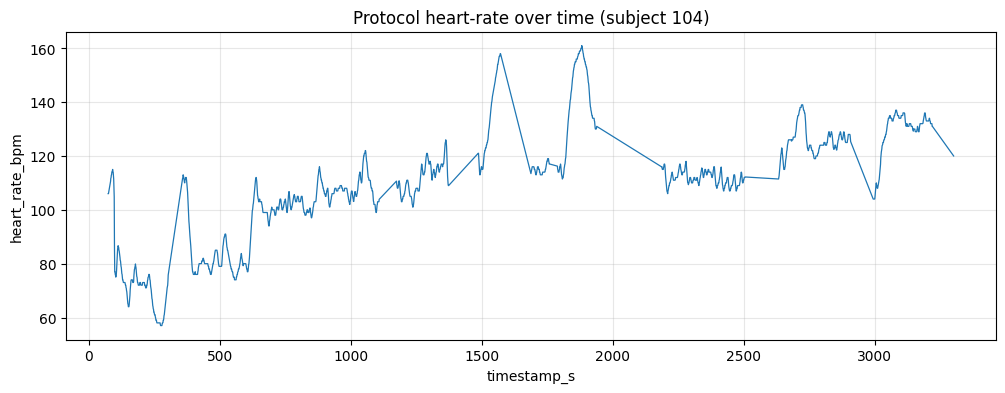

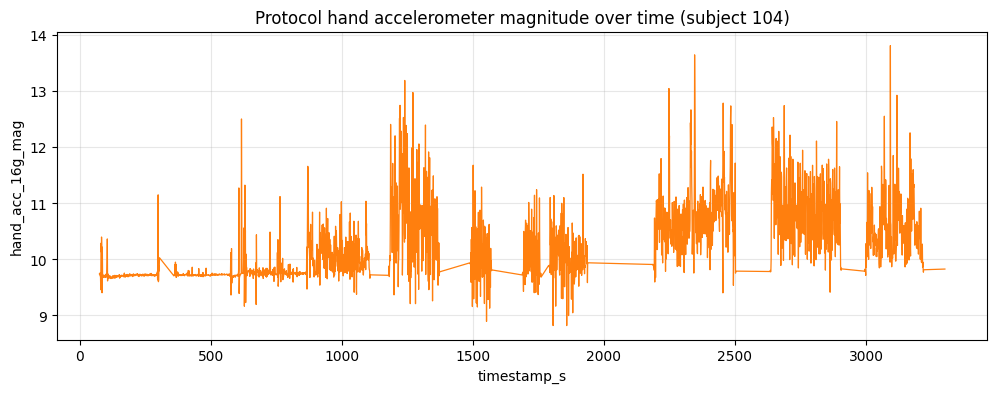

Saved plot: /Users/felipelorenzi/Documents/pamap2_telemetry/pamap2_telemetry/artifacts/figures/phase1_protocol_hr_timeseries_subject104.png
Saved plot: /Users/felipelorenzi/Documents/pamap2_telemetry/pamap2_telemetry/artifacts/figures/phase1_protocol_hand_acc_timeseries_subject104.png


In [6]:
# Create quick audit plots for one representative subject.
available_subjects = sorted(protocol_per_second_df["subject_id"].unique().tolist())
subject_for_plots = 104 if 104 in available_subjects else available_subjects[0]

subject_plot_df = (
    protocol_per_second_df[protocol_per_second_df["subject_id"] == subject_for_plots]
    .sort_values("timestamp_s")
    .copy()
)

if subject_plot_df.empty:
    raise ValueError("No rows available for audit plotting.")

# Plot heart-rate over time for the selected subject.
hr_plot_path = ARTIFACT_FIGURES_DIR / f"phase1_protocol_hr_timeseries_subject{subject_for_plots}.png"
fig_hr, ax_hr = plt.subplots(figsize=(12, 4))
ax_hr.plot(subject_plot_df["timestamp_s"], subject_plot_df["heart_rate_bpm"], linewidth=0.9)
ax_hr.set_title(f"Protocol heart-rate over time (subject {subject_for_plots})")
ax_hr.set_xlabel("timestamp_s")
ax_hr.set_ylabel("heart_rate_bpm")
ax_hr.grid(alpha=0.3)
fig_hr.savefig(hr_plot_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig_hr)

# Plot hand accelerometer magnitude over time for the same subject.
acc_plot_path = ARTIFACT_FIGURES_DIR / f"phase1_protocol_hand_acc_timeseries_subject{subject_for_plots}.png"
fig_acc, ax_acc = plt.subplots(figsize=(12, 4))
ax_acc.plot(subject_plot_df["timestamp_s"], subject_plot_df["hand_acc_16g_mag"], linewidth=0.9, color="tab:orange")
ax_acc.set_title(f"Protocol hand accelerometer magnitude over time (subject {subject_for_plots})")
ax_acc.set_xlabel("timestamp_s")
ax_acc.set_ylabel("hand_acc_16g_mag")
ax_acc.grid(alpha=0.3)
fig_acc.savefig(acc_plot_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig_acc)

print(f"Saved plot: {hr_plot_path}")
print(f"Saved plot: {acc_plot_path}")

## Phase 1 Summary for the Project

Phase 1 is complete. This stage turned the raw PAMAP2 package into a clean and auditable starting point for the rest of the MVP.

### Important steps completed

1. Organized the raw dataset information without changing original source files.
   - Added a tidy metadata layer with schema mapping, activity labels, subject info, and file manifests.
2. Mapped raw `.dat` columns to clear names.
   - This makes the dataset easier to read, debug, and explain.
3. Ingested Protocol sessions as the main source.
   - Optional sessions were tracked separately to reduce leakage risk.
4. Audited data quality by subject.
   - Checked row counts, missing heart-rate values, activity distribution, and invalid/transient labels.
5. Added complete audit outputs for Phase 1 closeout.
   - Saved selected-column missingness summary and observed HR summary stats.
   - Saved quick time-series audit plots for heart rate and hand accelerometer magnitude.
6. Built the interim 1-second telemetry table.
   - Saved to `data/interim/pamap2_per_second.parquet`.
7. Saved audit outputs for traceability.
   - Metrics tables were saved to `artifacts/metrics/`.

### Key findings

- Heart-rate values are missing in many raw rows (about 90.9% per subject at 100 Hz).
  - This is expected because heart rate is sampled much slower than IMU signals.
- Activity ID `0` (transient/other) is common and was removed from supervised activity targets.
- Subject `109` has much less Protocol data than other subjects.
- Protocol and Optional files overlap on subjects `101, 105, 106, 108, 109`.
  - This overlap is a leakage risk if sessions are mixed carelessly.

### Final Phase 1 activity set for MVP

Kept activity IDs:
- `1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17`

Plain labels:
- lying, sitting, standing, walking, running, cycling, nordic walking,
  ascending stairs, descending stairs, vacuum cleaning, ironing

### Why this matters for the next phases

- Strict Phase 2 checks now confirm the interim telemetry table is complete and valid.
- Phase 3 can now build lagged and rolling features from a stable 1-second table.
- The project now has stronger reproducibility, lower leakage risk, and better interview defensibility.